In [3]:
#import sys
#!{sys.executable} -m pip install tensorflow-cpu numpy matplotlib

In [4]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
# ============================================================
# PART 1 — DOG VS CAT IMAGE CLASSIFIER
# ============================================================

# ── STEP 1: SETUP ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
import os

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Keras version: 3.14.0
GPU available: []



STEP 2: LOADING AND PREPARING DATA
Loading CIFAR-10 dataset...
Full dataset — Training: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)

CIFAR-10 classes:
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck

Filtered dataset:
  Training: 10000 images
  Test:     2000 images
  Image shape: (32, 32, 3)

Training — Cats: 5000, Dogs: 5000
Test     — Cats: 1000,  Dogs: 1000

Flattened shape: (10000, 3072)
✓ Saved sample_images.png


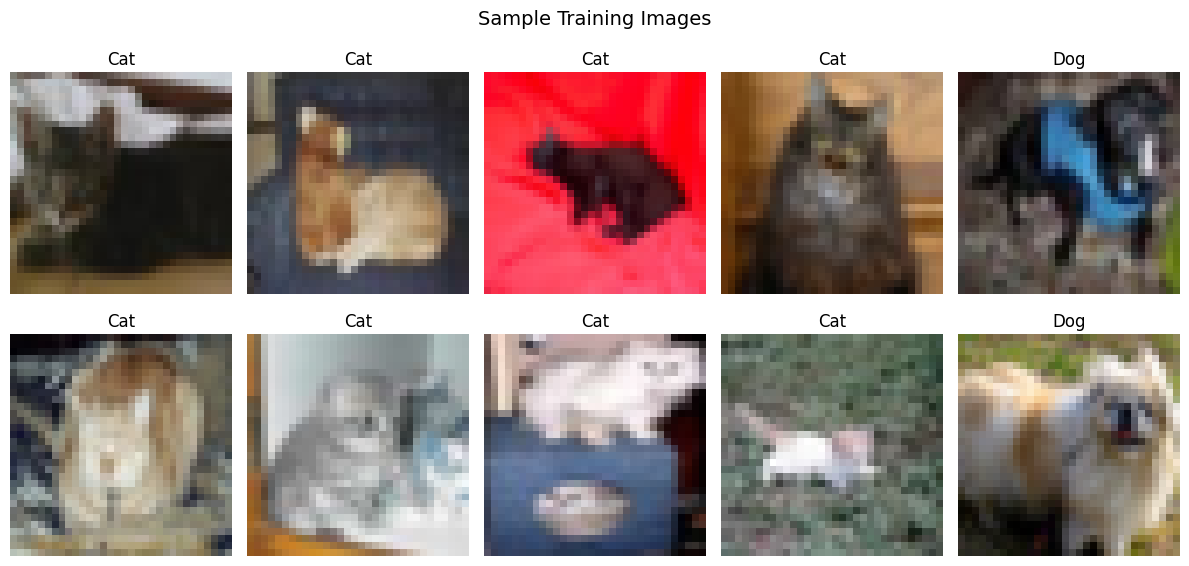

In [6]:
# ── STEP 2: LOAD AND PREPARE DATA ────────────────────────────────
print("\n" + "=" * 50)
print("STEP 2: LOADING AND PREPARING DATA")
print("=" * 50)

# Load CIFAR-10
print("Loading CIFAR-10 dataset...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

print(f"Full dataset — Training: {x_train_full.shape}, Test: {x_test_full.shape}")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nCIFAR-10 classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# Filter to cats (3) and dogs (5)
cat_class = 3
dog_class = 5

# Training set
train_mask = np.isin(y_train_full.flatten(), [cat_class, dog_class])
x_train    = x_train_full[train_mask]
y_train    = y_train_full[train_mask]
y_train    = np.where(y_train.flatten() == cat_class, 0, 1)

# Test set
test_mask = np.isin(y_test_full.flatten(), [cat_class, dog_class])
x_test    = x_test_full[test_mask]
y_test    = y_test_full[test_mask]
y_test    = np.where(y_test.flatten() == cat_class, 0, 1)

print(f"\nFiltered dataset:")
print(f"  Training: {x_train.shape[0]} images")
print(f"  Test:     {x_test.shape[0]} images")
print(f"  Image shape: {x_train.shape[1:]}")

print(f"\nTraining — Cats: {(y_train==0).sum()}, Dogs: {(y_train==1).sum()}")
print(f"Test     — Cats: {(y_test==0).sum()},  Dogs: {(y_test==1).sum()}")

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Flatten for dense network (32x32x3 = 3072)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat  = x_test.reshape(x_test.shape[0], -1)

print(f"\nFlattened shape: {x_train_flat.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_train[i])
    axes[row, col].set_title('Cat' if y_train[i] == 0 else 'Dog')
    axes[row, col].axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
print("✓ Saved sample_images.png")
plt.show()

In [7]:
# ── STEP 3: BUILD NEURAL NETWORK ─────────────────────────────────
print("\n" + "=" * 50)
print("STEP 3: BUILDING NEURAL NETWORK")
print("=" * 50)

model = keras.Sequential([
    layers.Dense(128, activation='relu',
                 input_shape=(3072,), name='hidden_layer_1'),
    layers.Dense(64,  activation='relu', name='hidden_layer_2'),
    layers.Dense(1,   activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")


STEP 3: BUILDING NEURAL NETWORK

Model Architecture:


c:\Users\dbyst\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 401,665


In [8]:
# ── STEP 4: TRAIN THE MODEL ───────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 4: TRAINING THE MODEL")
print("=" * 50)

EPOCHS     = 20
BATCH_SIZE = 32

print(f"Training for {EPOCHS} epochs, batch size {BATCH_SIZE}...")

history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_flat, y_test),
    verbose=1
)

print("\n✓ Training complete!")


STEP 4: TRAINING THE MODEL
Training for 20 epochs, batch size 32...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5583 - loss: 0.7091 - val_accuracy: 0.5870 - val_loss: 0.6708
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5768 - loss: 0.6714 - val_accuracy: 0.5925 - val_loss: 0.6666
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5805 - loss: 0.6700 - val_accuracy: 0.5945 - val_loss: 0.6599
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5842 - loss: 0.6687 - val_accuracy: 0.6095 - val_loss: 0.6629
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5929 - loss: 0.6618 - val_accuracy: 0.5995 - val_loss: 0.6678
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5998 - loss: 0.6573 - val_accuracy: 0.6050 - val_loss: 0.6634
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6033 - loss: 0.6551 - val_accuracy: 0.5985 - val_loss: 0.6728
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━


STEP 5: EVALUATING THE MODEL
Test Loss:     0.6712
Test Accuracy: 0.5900 (59.00%)
Manual check:  1180/2000 (59.00%)
✓ Saved training_history.png


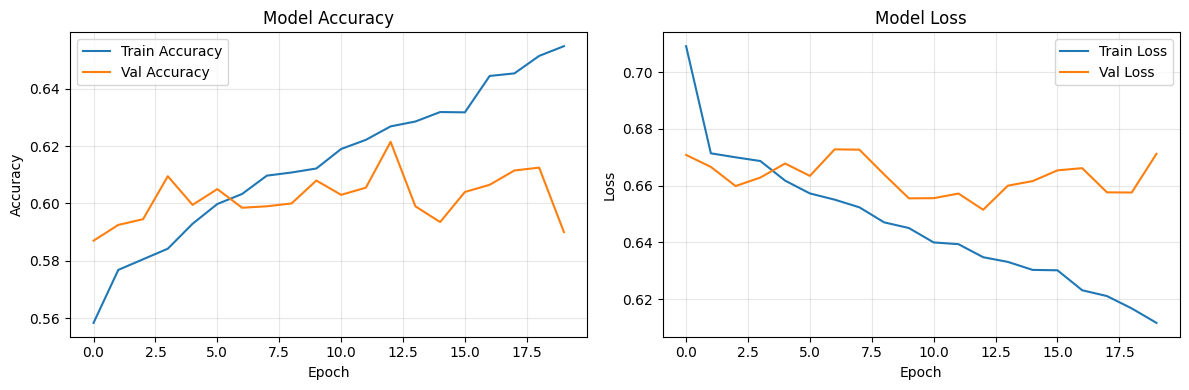

✓ Saved sample_predictions.png


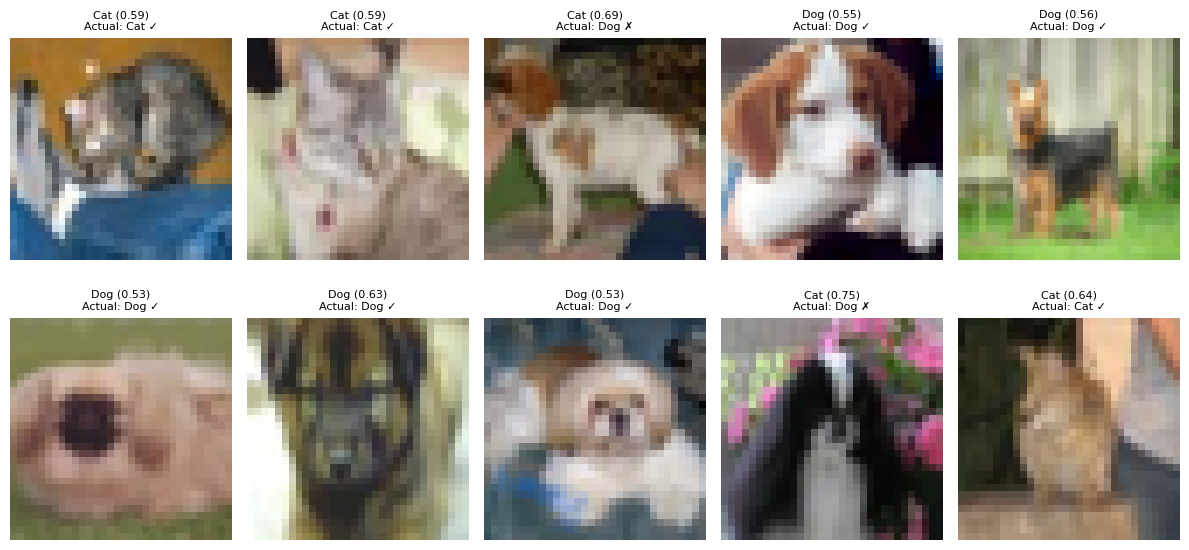

In [9]:
# ── STEP 5: EVALUATE ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 5: EVALUATING THE MODEL")
print("=" * 50)

test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Manual accuracy check
predictions       = model.predict(x_test_flat, verbose=0)
predicted_classes = (predictions > 0.5).astype(int).flatten()
correct           = (predicted_classes == y_test).sum()
print(f"Manual check:  {correct}/{len(y_test)} ({correct/len(y_test)*100:.2f}%)")

# Training history plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("✓ Saved training_history.png")
plt.show()

# Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row, col  = i // 5, i % 5
    img       = x_test[i].reshape(1, -1)
    pred      = model.predict(img, verbose=0)[0][0]
    pred_cls  = 'Dog' if pred > 0.5 else 'Cat'
    confidence= pred if pred > 0.5 else 1 - pred
    actual    = 'Dog' if y_test[i] == 1 else 'Cat'
    correct   = '✓' if (pred > 0.5) == (y_test[i] == 1) else '✗'

    axes[row, col].imshow(x_test[i])
    axes[row, col].set_title(
        f'{pred_cls} ({confidence:.2f})\nActual: {actual} {correct}',
        fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print("✓ Saved sample_predictions.png")
plt.show()

In [11]:
# ── STEP 6: EXPORT MODEL WEIGHTS ─────────────────────────────────
print("\n" + "=" * 50)
print("STEP 6: EXPORTING MODEL WEIGHTS")
print("=" * 50)

os.makedirs('saved_models', exist_ok=True)

# Method 1 — full model (keras format)
model_path = 'saved_models/dog_cat_classifier_full.keras'
model.save(model_path)
print(f"✓ Full model:    {model_path} "
      f"({os.path.getsize(model_path)/1024/1024:.2f} MB)")

# Method 2 — weights only
weights_path = 'saved_models/dog_cat_classifier.weights.h5'
model.save_weights(weights_path)
print(f"✓ Weights only:  {weights_path} "
      f"({os.path.getsize(weights_path)/1024/1024:.2f} MB)")

# Method 3 — export for TFLite/serving (Keras 3 compatible)
export_path = 'saved_models/dog_cat_classifier_export.h5'
model.save(export_path)
print(f"✓ H5 export:     {export_path} "
      f"({os.path.getsize(export_path)/1024/1024:.2f} MB)")

# Verify loading works
print("\nVerifying saved model loads correctly...")
loaded_model = keras.models.load_model(model_path)
_, loaded_acc = loaded_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Original accuracy: {test_accuracy:.4f}")
print(f"Loaded accuracy:   {loaded_acc:.4f}")
print(f"Match: {'✓' if abs(loaded_acc - test_accuracy) < 0.001 else '✗'}")
print("\n✓ Model weights exported successfully!")


STEP 6: EXPORTING MODEL WEIGHTS
✓ Full model:    saved_models/dog_cat_classifier_full.keras (4.62 MB)
✓ Weights only:  saved_models/dog_cat_classifier.weights.h5 (4.62 MB)
✓ H5 export:     saved_models/dog_cat_classifier_export.h5 (4.63 MB)

Verifying saved model loads correctly...
Original accuracy: 0.5900
Loaded accuracy:   0.5900
Match: ✓

✓ Model weights exported successfully!


In [12]:
# ── STEP 7: EXPERIMENTATION ───────────────────────────────────────
print("\n" + "=" * 50)
print("STEP 7: EXPERIMENTATION")
print("=" * 50)

experiments = [
    {
        "name": "Deeper network (4 layers)",
        "layers": [256, 128, 64, 32],
        "activation": "relu",
        "optimizer": "adam",
        "epochs": 20,
        "batch_size": 32
    },
    {
        "name": "Wider network (512 neurons)",
        "layers": [512, 256],
        "activation": "relu",
        "optimizer": "adam",
        "epochs": 20,
        "batch_size": 32
    },
    {
        "name": "Different optimizer (SGD)",
        "layers": [128, 64],
        "activation": "relu",
        "optimizer": "sgd",
        "epochs": 20,
        "batch_size": 32
    },
    {
        "name": "Different activation (tanh)",
        "layers": [128, 64],
        "activation": "tanh",
        "optimizer": "adam",
        "epochs": 20,
        "batch_size": 32
    },
    {
        "name": "Larger batch size (128)",
        "layers": [128, 64],
        "activation": "relu",
        "optimizer": "adam",
        "epochs": 20,
        "batch_size": 128
    }
]

results = []

for exp in experiments:
    print(f"\nRunning: {exp['name']}...")

    # Build model
    exp_model = keras.Sequential()
    exp_model.add(layers.Dense(
        exp["layers"][0],
        activation=exp["activation"],
        input_shape=(3072,)
    ))
    for units in exp["layers"][1:]:
        exp_model.add(layers.Dense(units, activation=exp["activation"]))
    exp_model.add(layers.Dense(1, activation='sigmoid'))

    exp_model.compile(
        optimizer=exp["optimizer"],
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train
    exp_history = exp_model.fit(
        x_train_flat, y_train,
        batch_size=exp["batch_size"],
        epochs=exp["epochs"],
        validation_data=(x_test_flat, y_test),
        verbose=0
    )

    _, exp_acc = exp_model.evaluate(x_test_flat, y_test, verbose=0)
    results.append({
        "name": exp["name"],
        "accuracy": exp_acc,
        "final_val_acc": exp_history.history['val_accuracy'][-1]
    })
    print(f"  ✓ Test accuracy: {exp_acc:.4f} ({exp_acc*100:.2f}%)")

# Summary table
print("\n" + "=" * 60)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 60)
print(f"{'Experiment':<35} {'Test Accuracy':>15}")
print("-" * 60)

# Include baseline
print(f"{'Baseline (128-64, relu, adam)':<35} {test_accuracy:>14.4f}")
for r in results:
    print(f"{r['name']:<35} {r['accuracy']:>14.4f}")

best = max(results, key=lambda x: x['accuracy'])
print(f"\n✓ Best experiment: {best['name']} ({best['accuracy']:.4f})")


STEP 7: EXPERIMENTATION

Running: Deeper network (4 layers)...
  ✓ Test accuracy: 0.6020 (60.20%)

Running: Wider network (512 neurons)...
  ✓ Test accuracy: 0.6010 (60.10%)

Running: Different optimizer (SGD)...
  ✓ Test accuracy: 0.6375 (63.75%)

Running: Different activation (tanh)...
  ✓ Test accuracy: 0.4995 (49.95%)

Running: Larger batch size (128)...
  ✓ Test accuracy: 0.5730 (57.30%)

EXPERIMENT RESULTS SUMMARY
Experiment                            Test Accuracy
------------------------------------------------------------
Baseline (128-64, relu, adam)               0.5900
Deeper network (4 layers)                   0.6020
Wider network (512 neurons)                 0.6010
Different optimizer (SGD)                   0.6375
Different activation (tanh)                 0.4995
Larger batch size (128)                     0.5730

✓ Best experiment: Different optimizer (SGD) (0.6375)
